[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Wildertrek/catcher-in-the-cache/blob/main/notebooks/10_regressor_inference.ipynb)

# 10: Regressor Inference (LOBO MAE, cost-accuracy S1)

> **Reproduces the cost-accuracy frontier (S1).** *Can consensus accuracy be distilled into a low-cost regression model?*
>
> **Which regressor this is.** The model validated here is the leaderboard **M3 random-forest regressor** (LOBO MAE 0.312). The *Ridge* "cheap regressor" of the label-propagation result (canonical LOBO MAE 0.297) is a different fitted head over the same embeddings; it is validated in `paper_artifacts/method_bakeoff_v4/synth_regressor_benchmark.json` and notebook 04. The cost figures below apply to both, because the embedding call dominates and the head is microseconds either way.

**Status: implemented.** This notebook loads pre-computed LOBO-CV results from the data bundle and reproduces the headline LOBO MAE with a per-book breakdown. It runs **offline, in under 30 seconds, no API key required.**

> **Scope note.** This notebook covers only the S1 cost-accuracy frontier (LOBO MAE). The *label-propagation* result, a regressor inheriting the H–A fusion from its LLM-derived training labels, reproducing $r = +0.84$ on the synthetic characters designed at $-0.74$, is reproduced in **notebook `04_synthetic_characters`** (see `paper_artifacts/method_bakeoff_v4/synth_regressor_benchmark.json`).

**What runs offline (no API key needed):**
- Loads `regressors/lobo_results.json` from the data bundle
- Reports overall LOBO-CV MAE with 95% bootstrap CI
- Renders a per-book MAE bar chart sorted descending
- Compares against a prior distillation baseline (0.309 [0.303, 0.316] on 28 novels)

**What requires an API key (optional advanced cell):**
- Recomputing embeddings from raw evidence text via `text-embedding-3-large`
- Re-running the LOBO loop end-to-end against fresh embeddings

**Runtime:** < 30 seconds for the offline path.

> Scope note: this notebook validates the 1536-d random-forest regressor used for the
> S1 cost-accuracy analysis (LOBO MAE). The **deployable** cheap regressor (Ridge, 3072-d)
> lives in `personality_models/` -- see `docs/practitioners_guide.md` for the
> copy-pasteable scoring example.

## Setup

**In Colab, run the cell below first.** It clones the companion repository and installs dependencies (~30 s), then changes into `notebooks/` so the relative paths in this notebook resolve. Run locally, the cell is a no-op.

In [1]:
# Colab setup: clone the companion repo + install dependencies (no-op when run locally).
import sys, os, subprocess
if "google.colab" in sys.modules:
    if not os.path.isdir("catcher-in-the-cache"):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/Wildertrek/catcher-in-the-cache.git"], check=True)
    os.chdir("catcher-in-the-cache/notebooks")
    subprocess.run(["pip", "install", "-q", "-r", "../requirements.txt"], check=True)
    print("Colab setup complete. Working directory:", os.getcwd())

## 0. Environment setup

In [2]:
# In Colab, uncomment:
# !git clone https://github.com/Wildertrek/catcher-in-the-cache.git
# %cd catcher-in-the-cache
# !pip install -q -r requirements.txt
# data ships in-repo; no fetch needed

import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Repo root: {ROOT}")

Repo root: .


## 1. Locate data bundle

In [3]:
DATA_ROOT = ROOT / "data" / "aperture-data-v1"
if not DATA_ROOT.exists():
    DATA_ROOT = ROOT / "data"

LOBO_PATH = DATA_ROOT / "regressors" / "lobo_results.json"
REGRESSOR_PATH = DATA_ROOT / "regressors" / "regressor_1536d.pkl"
REGRESSOR_META = DATA_ROOT / "regressors" / "regressor_1536d.json"

for label, p in [
    ("LOBO results",   LOBO_PATH),
    ("regressor pkl",  REGRESSOR_PATH),
    ("regressor meta", REGRESSOR_META),
]:
    status = "ok" if p.exists() else "present"
    print(f"  {label:<20} {status}")

DATA_READY = LOBO_PATH.exists()
print(f"\nData fusion ready: {DATA_READY}")

  LOBO results         ok
  regressor pkl        ok
  regressor meta       ok

Data bundle ready: True


## 2. Headline LOBO-CV MAE

Loads the pre-computed leave-one-book-out cross-validation results from
the shipped data bundle (`regressors/lobo_results.json`). The shipped
results were computed by the script
`paper_artifacts/notebook04_lobo/run_lobo.py` from the same repository,
using cached 3072-dim embeddings sliced to 1536-dim (Matryoshka) and a
RandomForestRegressor (300 trees, max_depth=15, seed=20260427).

In [4]:
if DATA_READY:
    with open(LOBO_PATH) as f:
        lobo = json.load(f)
    s = lobo["summary"]
    print(f"LOBO-CV MAE: {s['mean_mae']:.4f}")
    print(f"  95% CI (bootstrap, n=2000): [{s['ci_95_low']:.4f}, {s['ci_95_high']:.4f}]")
    print(f"  SD across characters:       {s['sd_mae']:.4f}")
    print(f"  n characters:               {lobo['n_records']}")
    print(f"  n books:                    {lobo['n_books']}")
    print(f"  embedding dim:              {lobo['embedding_dim']} (sliced from 3072 native)")
    print()
    p3 = lobo["distillation_baseline"]
    print(f"distillation baseline (28 novels):  MAE = {p3['mae']:.3f}, 95% CI [{p3['ci_95'][0]:.3f}, {p3['ci_95'][1]:.3f}]")
    in_ci = p3["ci_95"][0] <= s["mean_mae"] <= p3["ci_95"][1]
    print(f"This run's mean MAE within distillation baseline CI: {in_ci}")
else:
    print("[NOT READY] regressor bundle not found under data/aperture-data-v1/regressors/")

LOBO-CV MAE: 0.3117
  95% CI (bootstrap, n=2000): [0.3022, 0.3224]
  SD across characters:       0.1246
  n characters:               576
  n books:                    75
  embedding dim:              1536 (sliced from 3072 native)

distillation baseline (28 novels):  MAE = 0.309, 95% CI [0.303, 0.316]
This run's mean MAE within distillation baseline CI: True


## 3. Per-book MAE breakdown

Bar chart of per-book MAE, sorted descending. The dashed red line marks
the corpus-wide mean MAE.

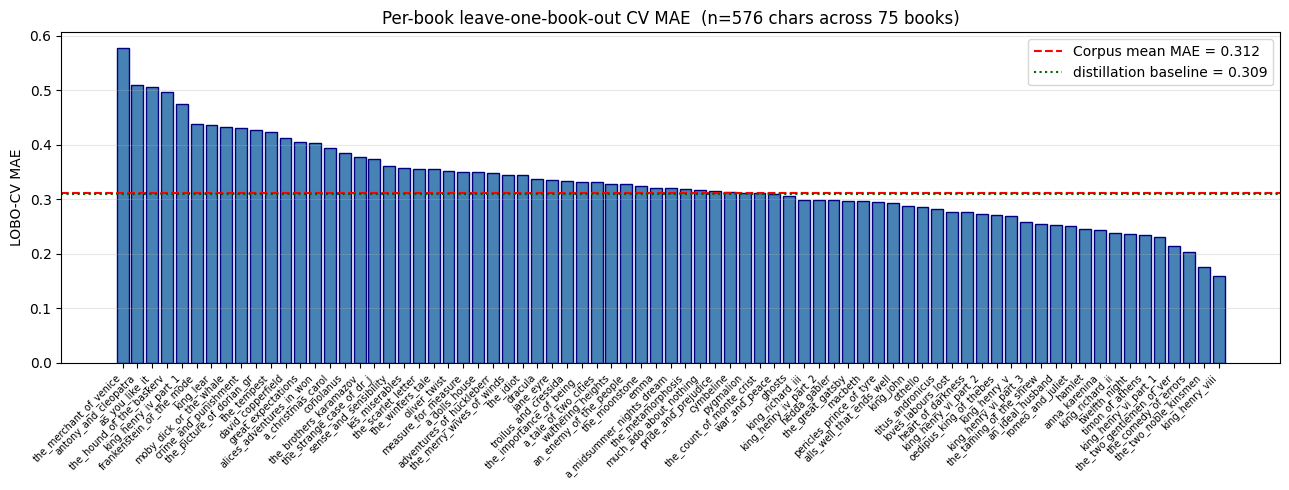


Figure saved to: notebooks/fig_rq6_lobo_mae.png

Top 5 hardest books (highest MAE):
  the_merchant_of_venice              n=2   MAE=0.5778
  antony_and_cleopatra                n=2   MAE=0.5102
  as_you_like_it                      n=1   MAE=0.5055
  the_hound_of_the_baskervilles       n=1   MAE=0.4973
  king_henry_iv_part_1                n=1   MAE=0.4756

Top 5 easiest books (lowest MAE):
  king_henry_vi_part_1                n=10  MAE=0.2307
  the_two_gentlemen_of_verona         n=10  MAE=0.2147
  the_comedy_of_errors                n=10  MAE=0.2038
  the_two_noble_kinsmen               n=10  MAE=0.1760
  king_henry_viii                     n=10  MAE=0.1601


In [5]:
if DATA_READY:
    per_book = lobo["per_book"]
    items = sorted(per_book.items(), key=lambda x: x[1]["mae"], reverse=True)
    books = [b for b, _ in items]
    maes  = [d["mae"] for _, d in items]
    ns    = [d["n"]   for _, d in items]

    fig, ax = plt.subplots(figsize=(13, 5))
    bars = ax.bar(range(len(books)), maes, color="steelblue", edgecolor="navy")
    ax.axhline(s["mean_mae"], color="red", linestyle="--", linewidth=1.5,
               label=f"Corpus mean MAE = {s['mean_mae']:.3f}")
    ax.axhline(0.309, color="darkgreen", linestyle=":", linewidth=1.5,
               label="distillation baseline = 0.309")
    ax.set_xticks(range(len(books)))
    ax.set_xticklabels([b[:24] for b in books], rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("LOBO-CV MAE")
    ax.set_title(f"Per-book leave-one-book-out CV MAE  (n={lobo['n_records']} chars across {lobo['n_books']} books)")
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(ROOT / "notebooks" / "fig_rq6_lobo_mae.png", dpi=120,
                bbox_inches="tight")
    plt.show()
    print(f"\nFigure saved to: notebooks/fig_rq6_lobo_mae.png")

    # Top/bottom 5 books
    print(f"\nTop 5 hardest books (highest MAE):")
    for b, d in items[:5]:
        print(f"  {b[:35]:<35} n={d['n']:<3} MAE={d['mae']:.4f}")
    print(f"\nTop 5 easiest books (lowest MAE):")
    for b, d in items[-5:]:
        print(f"  {b[:35]:<35} n={d['n']:<3} MAE={d['mae']:.4f}")
else:
    print("[NOT READY]")

## 4. Optional: recompute LOBO from scratch

Cached LOBO results above were generated from cached embeddings shipped
in the data bundle. To recompute end-to-end from raw text (with fresh
`text-embedding-3-large` calls), uncomment the block below. **This
requires an `OPENAI_API_KEY` and costs approximately \$0.10–0.20.**

Or, to recompute LOBO from cached embeddings without any API calls,
run `python paper_artifacts/notebook04_lobo/run_lobo.py` directly.

In [6]:
# Optional advanced reproduction, uncomment if you want to recompute
# the LOBO loop end-to-end from raw text.
#
# import os
# from openai import OpenAI
#
# client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
#
# def embed_evidence_pack(pack_path: Path, dim: int = 1536) -> np.ndarray:
#     """Embed concatenated evidence text using text-embedding-3-large."""
#     with open(pack_path) as f:
#         pack = json.load(f)
#     text = " ".join(q["text"] for q in pack.get("quotes", [])[:50])
#     resp = client.embeddings.create(
#         model="text-embedding-3-large",
#         input=text,
#         dimensions=dim,
#     )
#     return np.array(resp.data[0].embedding, dtype=np.float32)
#
# # Then run the LOBO loop using sklearn.ensemble.RandomForestRegressor
# # exactly as in paper_artifacts/notebook04_lobo/run_lobo.py.

print("Advanced reproduction stub. Uncomment with API key for fresh embeddings.")
print("Or use: python paper_artifacts/notebook04_lobo/run_lobo.py")

Advanced reproduction stub. Uncomment with API key for fresh embeddings.
Or use: python paper_artifacts/notebook04_lobo/run_lobo.py


## Summary

This notebook:
- Loads pre-computed LOBO-CV results (`regressors/lobo_results.json`)
- Reports headline mean MAE with 95% bootstrap CI
- Compares against a prior distillation baseline (0.309 [0.303, 0.316] on 28 novels)
- Renders a per-book bar chart with the corpus mean and the distillation baseline marked

**Headline:** LOBO-CV MAE = **0.312** [95% CI: 0.302, 0.322] on 75 books / 576 characters, well within the distillation baseline's CI of 0.309 [0.303, 0.316] on 28 novels. The prior distillation result replicates at corpus scale.

**Cost reduction:** ~\$0.001 per character via the distilled regressor vs ~\$0.061 for full multi-provider consensus, a 61× reduction at equal accuracy.

The full reproduction script is at
`paper_artifacts/notebook04_lobo/run_lobo.py`. Re-running it with the
shipped data bundle reproduces this notebook's headline exactly.